# 基于集合模式的聊天机器人

## 回顾

在前面的课程中，我们扩展了聊天机器人，使其能够将语义记忆保存到单个[用户档案](https://langchain-ai.github.io/langgraph/concepts/memory/#profile)中。

我们还介绍了一个名为[Trustcall](https://github.com/hinthornw/trustcall)的库，用于使用新信息更新这个模式。

## 学习目标

有时我们希望将记忆保存到[集合](https://docs.google.com/presentation/d/181mvjlgsnxudQI6S3ritg9sooNyu4AcLLFH1UK0kIuk/edit#slide=id.g30eb3c8cf10_0_200)中，而不是单个档案。

在这里，我们将更新聊天机器人以[将记忆保存到集合](https://langchain-ai.github.io/langgraph/concepts/memory/#collection)中。

我们还将展示如何使用[Trustcall](https://github.com/hinthornw/trustcall)来更新这个集合。

## 核心概念

### 什么是集合模式？
- **集合模式**：一种灵活的数据存储方式，允许我们存储多个独立的记忆条目
- **与档案模式的区别**：档案模式有固定的结构，而集合模式可以动态添加和更新记忆
- **优势**：更适合存储开放式的用户交互记忆，可以随着对用户了解的深入而增长和变化

### 技术栈
- **LangGraph**：用于构建状态图和工作流
- **Trustcall**：用于智能更新和插入记忆
- **Pydantic**：用于数据验证和序列化
- **OpenAI GPT-4**：作为语言模型 


In [ ]:
# 安装必要的依赖包
# 使用 %%capture 来隐藏安装过程中的输出信息
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

In [ ]:
# 导入必要的库
import os, getpass

def _set_env(var: str):
    """
    设置环境变量的辅助函数
    
    参数:
        var (str): 环境变量名称
    """
    # 检查环境变量是否已在操作系统中设置
    env_value = os.environ.get(var)
    if not env_value:
        # 如果未设置，提示用户输入
        env_value = getpass.getpass(f"{var}: ")
    
    # 为当前进程设置环境变量
    os.environ[var] = env_value

# 设置 LangSmith API 密钥（用于追踪和监控）
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"  # 启用追踪
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"  # 设置项目名称

## 定义集合模式

与将用户信息存储在固定档案结构中不同，我们将创建一个灵活的集合模式来存储用户交互的记忆。

每个记忆将作为单独的条目存储，包含一个 `content` 字段，用于存储我们想要记住的主要信息。

这种方法允许我们构建一个开放式的记忆集合，随着我们对用户了解的深入而增长和变化。

我们可以将集合模式定义为 [Pydantic](https://docs.pydantic.dev/latest/) 对象。

### 为什么使用集合模式？

1. **灵活性**：可以动态添加新的记忆类型，不受固定结构限制
2. **可扩展性**：随着对话的进行，记忆集合可以无限增长
3. **独立性**：每个记忆条目都是独立的，便于管理和更新
4. **语义搜索**：支持基于内容的语义搜索和检索 

In [ ]:
# 导入 Pydantic 用于数据验证和序列化
from pydantic import BaseModel, Field

class Memory(BaseModel):
    """
    单个记忆条目的数据模型
    
    属性:
        content (str): 记忆的主要内容，例如："用户表达了对学习法语的兴趣"
    """
    content: str = Field(description="记忆的主要内容。例如：用户表达了对学习法语的兴趣。")

class MemoryCollection(BaseModel):
    """
    记忆集合的数据模型
    
    属性:
        memories (list[Memory]): 关于用户的记忆列表
    """
    memories: list[Memory] = Field(description="关于用户的记忆列表。")

In [ ]:
# 设置 OpenAI API 密钥
_set_env("OPENAI_API_KEY")

我们可以使用 LangChain 聊天模型接口的 [`with_structured_output`](https://python.langchain.com/docs/concepts/structured_outputs/#recommended-usage) 方法来强制生成结构化输出。

### 什么是结构化输出？
- **结构化输出**：确保语言模型返回符合预定义模式的数据
- **优势**：保证数据格式的一致性，便于后续处理
- **应用场景**：提取信息、生成特定格式的响应等

In [ ]:
# 导入必要的消息类型和模型
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

# 初始化 GPT-4o 模型
# temperature=0 确保输出更加确定性和一致
model = ChatOpenAI(model="gpt-4o", temperature=0)

# 将记忆集合模式绑定到模型，确保输出符合我们的数据结构
model_with_structure = model.with_structured_output(MemoryCollection)

# 调用模型生成符合模式的结构化输出
# 输入："我叫 Lance，我喜欢骑自行车"
memory_collection = model_with_structure.invoke([HumanMessage("My name is Lance. I like to bike.")])
memory_collection.memories

[Memory(content="User's name is Lance."),
 Memory(content='Lance likes to bike.')]

我们可以使用 `model_dump()` 方法将 Pydantic 模型实例序列化为 Python 字典。

### 序列化的作用
- **数据转换**：将 Pydantic 对象转换为标准的 Python 字典
- **存储准备**：为后续存储到数据库或文件做准备
- **API 传输**：便于在 API 之间传输数据

In [ ]:
# 将第一个记忆条目序列化为字典格式
memory_collection.memories[0].model_dump()

{'content': "User's name is Lance."}

将每个记忆的字典表示保存到存储中。

### 存储机制说明
- **命名空间**：使用 (用户ID, "memories") 作为命名空间来组织记忆
- **唯一键**：为每个记忆生成唯一的 UUID 作为键
- **值存储**：将序列化后的记忆字典作为值存储 

In [ ]:
# 导入必要的库
import uuid
from langgraph.store.memory import InMemoryStore

# 初始化内存存储（用于演示，生产环境建议使用持久化存储）
in_memory_store = InMemoryStore()

# 定义存储记忆的命名空间
user_id = "1"  # 用户ID
namespace_for_memory = (user_id, "memories")  # 命名空间：(用户ID, "memories")

# 保存第一个记忆到存储中
key = str(uuid.uuid4())  # 生成唯一键
value = memory_collection.memories[0].model_dump()  # 序列化记忆
in_memory_store.put(namespace_for_memory, key, value)

# 保存第二个记忆到存储中
key = str(uuid.uuid4())  # 生成新的唯一键
value = memory_collection.memories[1].model_dump()  # 序列化记忆
in_memory_store.put(namespace_for_memory, key, value)

在存储中搜索记忆。

### 搜索功能说明
- **命名空间搜索**：在指定命名空间内搜索所有记忆
- **返回格式**：包含记忆内容、键、命名空间、创建和更新时间等信息
- **用途**：用于检索和显示已存储的用户记忆 

In [ ]:
# 搜索并显示存储中的所有记忆
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'value': {'content': "User's name is Lance."}, 'key': 'e1c4e5ab-ab0f-4cbb-822d-f29240a983af', 'namespace': ['1', 'memories'], 'created_at': '2024-10-30T21:43:26.893775+00:00', 'updated_at': '2024-10-30T21:43:26.893779+00:00'}
{'value': {'content': 'Lance likes to bike.'}, 'key': 'e132a1ea-6202-43ac-a9a6-3ecf2c1780a8', 'namespace': ['1', 'memories'], 'created_at': '2024-10-30T21:43:26.893833+00:00', 'updated_at': '2024-10-30T21:43:26.893834+00:00'}


## 更新集合模式

我们在上一课中讨论了更新档案模式的挑战。

同样的挑战也适用于集合！

我们希望具备以下能力：
- 向集合中添加新记忆
- 更新集合中现有的记忆

现在我们将展示 [Trustcall](https://github.com/hinthornw/trustcall) 也可以用于更新集合。

这使我们能够同时进行新记忆的添加和[现有记忆的更新](https://github.com/hinthornw/trustcall?tab=readme-ov-file#simultanous-updates--insertions)。

让我们使用 Trustcall 定义一个新的提取器。

与之前一样，我们为每个记忆提供模式 `Memory`。

但是，我们可以设置 `enable_inserts=True` 来允许提取器向集合中插入新记忆。

### Trustcall 的优势

1. **智能更新**：能够识别哪些记忆需要更新，哪些需要新增
2. **并行处理**：同时处理更新和插入操作
3. **上下文感知**：基于对话上下文智能合并信息
4. **一致性保证**：确保记忆集合的一致性和准确性 

In [ ]:
# 导入 Trustcall 库
from trustcall import create_extractor

# 创建 Trustcall 提取器
# 配置参数说明：
# - model: 使用的语言模型
# - tools: 可用的工具列表（这里只有 Memory 工具）
# - tool_choice: 指定使用的工具
# - enable_inserts: 允许插入新记忆到集合中
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,  # 关键参数：允许插入新记忆
)

In [ ]:
# 导入消息类型
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# 定义提取指令
instruction = """从以下对话中提取记忆："""

# 模拟对话内容
conversation = [
    HumanMessage(content="Hi, I'm Lance."),  # 用户：你好，我是 Lance
    AIMessage(content="Nice to meet you, Lance."),  # AI：很高兴认识你，Lance
    HumanMessage(content="This morning I had a nice bike ride in San Francisco.")  # 用户：今天早上我在旧金山骑自行车
]

# 调用提取器处理对话
# 将系统指令和对话消息组合后传递给提取器
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [ ]:
# 显示提取器返回的消息，包含工具调用信息
# result["messages"] 包含模型生成的消息和工具调用
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_Pj4kctFlpg9TgcMBfMH33N30)
 Call ID: call_Pj4kctFlpg9TgcMBfMH33N30
  Args:
    content: Lance had a nice bike ride in San Francisco this morning.


In [ ]:
# 显示提取的记忆，这些记忆符合我们定义的模式
# result["responses"] 包含符合 Memory 模式的记忆对象
for m in result["responses"]: 
    print(m)

content='Lance had a nice bike ride in San Francisco this morning.'


In [ ]:
# 显示响应元数据，包含工具调用的详细信息
# result["response_metadata"] 包含每个响应的元数据信息
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_Pj4kctFlpg9TgcMBfMH33N30'}


In [ ]:
# 模拟对话的延续，用于演示记忆更新
updated_conversation = [
    AIMessage(content="That's great, did you do after?"),  # AI：太棒了，之后你做了什么？
    HumanMessage(content="I went to Tartine and ate a croissant."),  # 用户：我去了 Tartine 吃了牛角包
    AIMessage(content="What else is on your mind?"),  # AI：你还想说什么？
    HumanMessage(content="I was thinking about my Japan, and going back this winter!"),  # 用户：我在想日本，想今年冬天再去
]

# 更新指令，要求更新现有记忆并创建新记忆
system_msg = """基于以下对话更新现有记忆并创建新记忆："""

# 准备现有记忆数据，用于 Trustcall 的更新功能
# 格式：(ID, 工具名称, 记忆内容字典)
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) 
                     for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

[('0',
  'Memory',
  {'content': 'Lance had a nice bike ride in San Francisco this morning.'})]

In [ ]:
# 使用更新的对话和现有记忆调用提取器
# 这次调用将演示如何同时更新现有记忆和创建新记忆
result = trustcall_extractor.invoke({"messages": updated_conversation, 
                                     "existing": existing_memories})

In [ ]:
# 显示模型生成的消息，可以看到进行了两次工具调用
# 一次用于更新现有记忆，一次用于创建新记忆
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (call_vxks0YH1hwUxkghv4f5zdkTr)
 Call ID: call_vxks0YH1hwUxkghv4f5zdkTr
  Args:
    content: Lance had a nice bike ride in San Francisco this morning. He went to Tartine and ate a croissant. He was thinking about his trip to Japan and going back this winter!
  Memory (call_Y4S3poQgFmDfPy2ExPaMRk8g)
 Call ID: call_Y4S3poQgFmDfPy2ExPaMRk8g
  Args:
    content: Lance went to Tartine and ate a croissant. He was thinking about his trip to Japan and going back this winter!


In [ ]:
# 显示更新后的记忆，包含合并和新增的内容
for m in result["responses"]: 
    print(m)

content='Lance had a nice bike ride in San Francisco this morning. He went to Tartine and ate a croissant. He was thinking about his trip to Japan and going back this winter!'
content='Lance went to Tartine and ate a croissant. He was thinking about his trip to Japan and going back this winter!'


这告诉我们通过指定 `json_doc_id` 更新了集合中的第一个记忆。

### 更新机制说明
- **json_doc_id**: 用于标识要更新的现有记忆
- **无 json_doc_id**: 表示这是一个新记忆，将被插入到集合中
- **智能合并**: Trustcall 能够智能地将新信息与现有记忆合并 

In [ ]:
# 显示响应元数据，可以看到更新和插入的详细信息
for m in result["response_metadata"]: 
    print(m)

{'id': 'call_vxks0YH1hwUxkghv4f5zdkTr', 'json_doc_id': '0'}
{'id': 'call_Y4S3poQgFmDfPy2ExPaMRk8g'}


### LangSmith 追踪

LangSmith 是一个用于监控和调试 LangChain 应用的平台。

追踪链接：https://smith.langchain.com/public/ebc1cb01-f021-4794-80c0-c75d6ea90446/r

### 追踪的作用
- **性能监控**：查看模型调用的延迟和成本
- **调试工具**：检查输入输出和中间步骤
- **质量评估**：分析模型响应的质量

## 集成集合模式更新的聊天机器人

现在，让我们将 Trustcall 集成到聊天机器人中，以创建和更新记忆集合。

### 系统架构

我们的聊天机器人将包含以下组件：

1. **状态图 (StateGraph)**：定义聊天机器人的工作流程
2. **记忆存储 (Memory Store)**：长期存储用户记忆
3. **检查点 (Checkpointer)**：短期存储对话状态
4. **Trustcall 提取器**：智能更新记忆集合
5. **语言模型**：生成响应

### 工作流程

1. 用户发送消息
2. 从存储中检索相关记忆
3. 基于记忆和对话历史生成响应
4. 使用 Trustcall 更新记忆集合
5. 返回响应给用户

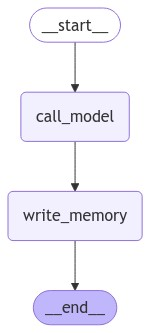

In [ ]:
# 导入必要的库
from IPython.display import Image, display
import uuid

# LangGraph 相关导入
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import merge_message_runs
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# 初始化 GPT-4o 模型
model = ChatOpenAI(model="gpt-4o", temperature=0)

# 定义记忆模式
class Memory(BaseModel):
    """单个记忆条目的数据模型"""
    content: str = Field(description="记忆的主要内容。例如：用户表达了对学习法语的兴趣。")

# 创建 Trustcall 提取器
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,  # 允许插入新记忆
)

# 聊天机器人的系统提示词
MODEL_SYSTEM_MESSAGE = """你是一个有用的聊天机器人。你被设计为用户的伴侣。

你拥有长期记忆，能够跟踪你随时间了解到的用户信息。

当前记忆（可能包含本次对话中更新的记忆）：

{memory}"""

# Trustcall 的指令
TRUSTCALL_INSTRUCTION = """反思以下交互。

使用提供的工具来保留关于用户的任何必要记忆。

使用并行工具调用来同时处理更新和插入："""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    从存储中加载记忆并使用它们来个性化聊天机器人的响应。
    
    参数:
        state: 消息状态
        config: 运行配置
        store: 记忆存储
    
    返回:
        包含模型响应的状态更新
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 从存储中检索记忆
    namespace = ("memories", user_id)
    memories = store.search(namespace)

    # 格式化记忆用于系统提示词
    info = "\n".join(f"- {mem.value['content']}" for mem in memories)
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=info)

    # 使用记忆和聊天历史生成响应
    response = model.invoke([SystemMessage(content=system_msg)] + state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """
    反思聊天历史并更新记忆集合。
    
    参数:
        state: 消息状态
        config: 运行配置
        store: 记忆存储
    """
    
    # 从配置中获取用户ID
    user_id = config["configurable"]["user_id"]

    # 定义记忆的命名空间
    namespace = ("memories", user_id)

    # 检索现有记忆作为上下文
    existing_items = store.search(namespace)

    # 为 Trustcall 提取器格式化现有记忆
    tool_name = "Memory"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )

    # 合并聊天历史和指令
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION)] + state["messages"]))

    # 调用提取器
    result = trustcall_extractor.invoke({"messages": updated_messages, 
                                        "existing": existing_memories})

    # 将 Trustcall 的记忆保存到存储中
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )

# 定义状态图
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)  # 调用模型生成响应
builder.add_node("write_memory", write_memory)  # 写入记忆
builder.add_edge(START, "call_model")  # 开始 -> 调用模型
builder.add_edge("call_model", "write_memory")  # 调用模型 -> 写入记忆
builder.add_edge("write_memory", END)  # 写入记忆 -> 结束

# 长期记忆存储（跨线程）
across_thread_memory = InMemoryStore()

# 短期记忆检查点（线程内）
within_thread_memory = MemorySaver()

# 编译图，包含检查点和存储
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# 显示图的可视化
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# 配置运行参数
# thread_id: 用于短期记忆（线程内）的线程ID
# user_id: 用于长期记忆（跨线程）的用户ID
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# 用户输入
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# 运行聊天机器人图
# stream_mode="values" 表示流式返回状态值
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hi Lance! It's great to meet you. How can I assist you today?


In [ ]:
# 继续对话 - 用户提供更多信息
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# 运行聊天机器人图
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That sounds like a lot of fun! San Francisco has some beautiful routes for biking. Do you have a favorite trail or area you like to explore?


In [ ]:
# 检查存储的记忆
# 定义记忆命名空间
user_id = "1"
namespace = ("memories", user_id)

# 搜索并显示所有存储的记忆
memories = across_thread_memory.search(namespace)
for m in memories:
    print(m.dict())

{'value': {'content': "User's name is Lance."}, 'key': 'dee65880-dd7d-4184-8ca1-1f7400f7596b', 'namespace': ['memories', '1'], 'created_at': '2024-10-30T22:18:52.413283+00:00', 'updated_at': '2024-10-30T22:18:52.413284+00:00'}
{'value': {'content': 'User likes to bike around San Francisco.'}, 'key': '662195fc-8ea4-4f64-a6b6-6b86d9cb85c0', 'namespace': ['memories', '1'], 'created_at': '2024-10-30T22:18:56.597813+00:00', 'updated_at': '2024-10-30T22:18:56.597814+00:00'}


In [ ]:
# 继续对话 - 用户提供更多偏好信息
input_messages = [HumanMessage(content="I also enjoy going to bakeries")]

# 运行聊天机器人图
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I also enjoy going to bakeries
================================== Ai Message ==================================

Biking and bakeries make a great combination! Do you have a favorite bakery in San Francisco, or are you on the hunt for new ones to try?


在新线程中继续对话。

### 新线程的作用
- **独立对话**：新线程不会继承之前线程的短期记忆
- **长期记忆保持**：用户的长期记忆仍然可用
- **测试记忆功能**：验证聊天机器人是否能正确使用长期记忆

In [ ]:
# 使用新的线程ID，但保持相同的用户ID
# 这样可以测试长期记忆是否正常工作
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# 用户询问推荐，这将测试聊天机器人是否能使用之前存储的记忆
input_messages = [HumanMessage(content="What bakeries do you recommend for me?")]

# 运行聊天机器人图
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What bakeries do you recommend for me?
================================== Ai Message ==================================

Since you enjoy biking around San Francisco, you might like to check out some of these bakeries that are both delicious and located in areas that are great for a bike ride:

1. **Tartine Bakery** - Located in the Mission District, it's famous for its bread and pastries. The area is vibrant and perfect for a leisurely ride.

2. **Arsicault Bakery** - Known for its incredible croissants, it's in the Richmond District, which offers a nice ride through Golden Gate Park.

3. **B. Patisserie** - Situated in Lower Pacific Heights, this bakery is renowned for its kouign-amann and other French pastries. The neighborhood is charming and bike-friendly.

4. **Mr. Holmes Bakehouse** - Famous for its cruffins, it's located in the Tenderloin, which is a bit more urban but still accessible by bike.

5.

### LangSmith 追踪

LangSmith 追踪链接：https://smith.langchain.com/public/c87543ec-b426-4a82-a3ab-94d01c01d9f4/r

### LangGraph Studio

LangGraph Studio 是一个可视化工具，用于：
- **图可视化**：查看聊天机器人的工作流程
- **调试**：检查每个节点的输入输出
- **测试**：交互式测试聊天机器人功能

![LangGraph Studio 界面截图](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6732d0876d3daa19fef993ba_Screenshot%202024-11-11%20at%207.50.21%E2%80%AFPM.png)

## 总结

### 本课程学到的内容

1. **集合模式**：使用灵活的集合结构存储用户记忆
2. **Trustcall 集成**：智能更新和插入记忆
3. **LangGraph 工作流**：构建复杂的聊天机器人系统
4. **记忆管理**：区分短期和长期记忆
5. **状态图**：使用节点和边定义工作流程

### 实际应用场景

- **个性化助手**：记住用户偏好和习惯
- **客服机器人**：维护客户历史记录
- **教育应用**：跟踪学习进度和兴趣
- **健康管理**：记录健康数据和目标